In [1]:
!pip install qdrant-client sentence-transformers transformers google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 7.1 MB/s eta 0:00:00


# Proyecto 4: Arquitectura RAG básica para detección de contradicciones normativas

**Cuaderno base:** `Cuaderno22-CC0C2.ipynb`  
**Tema central:** pipeline de retrieval y generación, integración de contexto recuperado en el prompt  
**Curso:** CC0C2 — Procesamiento del Lenguaje Natural — Práctica Calificada 4

---

## Objetivo

El Cuaderno22 implementa `rag_tool()` como un **mock**: búsqueda por coincidencia léxica de palabras clave sobre un diccionario `KNOWLEDGE_BASE` de 9 entradas, sin embeddings ni vector store reales.

Este proyecto **reconstruye esa línea base** y la compara contra una **variante real**: un pipeline RAG con embeddings densos (bge-m3), vector store (Qdrant) y un módulo adicional de clasificación NLI, aplicado a un problema concreto: **detección de contradicciones normativas en artículos del Código Civil Peruano** (Libro I, Personas Naturales, Art. 1–100).

Esta es la misma arquitectura de mi proyecto de tesis: *"Detección Automática de Contradicciones Normativas en Textos Jurídicos Peruanos Mediante RAG e Inferencia de Lenguaje Natural"*. La PC4 implementa una versión reducida y reproducible de ese sistema.


## Celda de verificación personal

In [2]:
# CELDA DE VERIFICACIÓN PERSONAL
STUDENT_NAME   = "Carlos Sinai Unda Miguel"
EXECUTION_DATE = "2026-06-25"
BASE_NOTEBOOK  = "Cuaderno22-CC0C2.ipynb"
MODEL_NAME     = "BAAI/bge-m3 (embeddings) + gemini-2.5-flash-lite (generación) + cross-encoder/nli-deberta-v3-base (NLI)"
SEED           = 42
CORPUS_SIZE    = "100 artículos (Código Civil Peruano, Libro I - Personas Naturales, Art. 1-100)"
VARIANT        = "RAG semántico (bge-m3 + Qdrant) vs RAG léxico (keyword matching, línea base del Cuaderno22)"
OBJECTIVE      = ("Comparar retrieval léxico (línea base del Cuaderno22) contra retrieval semántico dense "
                  "con embeddings reales, aplicado a la detección de contradicciones normativas entre "
                  "artículos del Código Civil Peruano que han sido modificados por reformas posteriores.")

print("Estudiante:    ", STUDENT_NAME)
print("Fecha:         ", EXECUTION_DATE)
print("Cuaderno base: ", BASE_NOTEBOOK)
print("Modelo:        ", MODEL_NAME)
print("Semilla:       ", SEED)
print("Corpus:        ", CORPUS_SIZE)
print("Variante:      ", VARIANT)
print()
print("Objetivo técnico:")
print(" ", OBJECTIVE)


Estudiante:     Carlos Sinai Unda Miguel
Fecha:          2026-06-25
Cuaderno base:  Cuaderno22-CC0C2.ipynb
Modelo:         BAAI/bge-m3 (embeddings) + gemini-2.5-flash-lite (generación) + cross-encoder/nli-deberta-v3-base (NLI)
Semilla:        42
Corpus:         100 artículos (Código Civil Peruano, Libro I - Personas Naturales, Art. 1-100)
Variante:       RAG semántico (bge-m3 + Qdrant) vs RAG léxico (keyword matching, línea base del Cuaderno22)

Objetivo técnico:
  Comparar retrieval léxico (línea base del Cuaderno22) contra retrieval semántico dense con embeddings reales, aplicado a la detección de contradicciones normativas entre artículos del Código Civil Peruano que han sido modificados por reformas posteriores.


---
## 1. Setup e instalación

Librerías necesarias: `sentence-transformers` (bge-m3), `qdrant-client` (vector store), `transformers` (NLI), `google-generativeai` (Gemini).

In [3]:
# 1. Instalación e imports
# !pip install sentence-transformers qdrant-client transformers google-generativeai torch -q

import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional
from collections import Counter

# Reproducibilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# aPI key de Gemini (Google AI Studio)
# Configuramos la variable de entorno antes de ejecutar

GEMINI_MODEL = "gemini-2.5-flash-lite"
print(f"Gemini configurado: {GEMINI_MODEL}")
print(f"Seed fijada: 42")


Gemini configurado: gemini-2.5-flash-lite
Seed fijada: 42


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


---
## 2. Línea base — `rag_tool()` del Cuaderno22 (retrieval léxico)

Esta es la función exacta del Cuaderno22, Sección 11 ("Conexión con RAG"). Es un **mock**: compara palabras clave contra un diccionario pequeño, sin embeddings.

In [4]:
# 2. LÍNEA BASE — código del Cuaderno22 (sin modificar)

KNOWLEDGE_BASE = {
    "rag": "RAG combina recuperación de evidencia externa con generación del LLM.",
    "embedding": "Un embedding es una representación vectorial densa de un texto.",
    "react": "ReAct estructura el ciclo pensamiento, acción y observación.",
    "guardrail": "Un guardrail restringe entradas, salidas, permisos o acciones del sistema.",
    "vector store": "Un vector store guarda embeddings junto con texto y metadatos.",
    "multiagente": "Un sistema multiagente coordina varios agentes especializados para resolver una tarea.",
    "orquestador": "Un orquestador coordina agentes, herramientas, memoria compartida y criterios de parada.",
    "critic": "Un agente critic revisa consistencia, evidencia, riesgos y calidad de una respuesta.",
    "blackboard": "Una memoria blackboard permite que varios agentes lean y escriban hallazgos compartidos.",
}

def rag_tool(query: str) -> Dict[str, Any]:
    """Línea base del Cuaderno22: retrieval por coincidencia léxica de palabras clave."""
    docs = []
    q = query.lower()
    for key, value in KNOWLEDGE_BASE.items():
        if key in q or any(tok in value.lower() for tok in q.split()):
            docs.append({"key": key, "text": value})
    return {"query": query, "top_k": len(docs[:3]), "documents": docs[:3]}

# Demostración con la consulta original del cuaderno
resultado = rag_tool("vector store y embedding")
print("Demostración rag_tool() del Cuaderno22:")
print(json.dumps(resultado, ensure_ascii=False, indent=2))
print()
print("PROBLEMA: este retrieval es léxico, no semántico.")
print("Si consulto con sinónimos o paráfrasis, NO encuentra nada relevante:")
print()
resultado_fail = rag_tool("¿cómo se almacenan representaciones numéricas de texto?")
print(json.dumps(resultado_fail, ensure_ascii=False, indent=2))
print()
print("0 documentos recuperados, aunque la KNOWLEDGE_BASE SÍ tiene la entrada 'embedding'")
print("  que responde exactamente a esa pregunta. Esta es la limitación que motiva")
print("  el resto de este proyecto: pasar de retrieval léxico a retrieval semántico.")


Demostración rag_tool() del Cuaderno22:
{
  "query": "vector store y embedding",
  "top_k": 3,
  "documents": [
    {
      "key": "embedding",
      "text": "Un embedding es una representación vectorial densa de un texto."
    },
    {
      "key": "react",
      "text": "ReAct estructura el ciclo pensamiento, acción y observación."
    },
    {
      "key": "vector store",
      "text": "Un vector store guarda embeddings junto con texto y metadatos."
    }
  ]
}

PROBLEMA: este retrieval es léxico, no semántico.
Si consulto con sinónimos o paráfrasis, NO encuentra nada relevante:

{
  "query": "¿cómo se almacenan representaciones numéricas de texto?",
  "top_k": 3,
  "documents": [
    {
      "key": "rag",
      "text": "RAG combina recuperación de evidencia externa con generación del LLM."
    },
    {
      "key": "embedding",
      "text": "Un embedding es una representación vectorial densa de un texto."
    },
    {
      "key": "react",
      "text": "ReAct estructura el ciclo 

---
## 3. Problema técnico: detección de contradicciones normativas

El Código Civil Peruano (D.L. 295, 1984) ha sido modificado por decenas de normas posteriores. Cuando un artículo se reforma, el texto **vigente** puede ser parcial o totalmente **incompatible** con versiones anteriores que aún circulan en copias, citas o sistemas no actualizados.

**Caso real que vamos a usar:** extraje directamente del PDF oficial del Código Civil Peruano (453 páginas, descarga del SPIJ) los artículos del **Libro I — Personas Naturales (Art. 1 a 100)**. De estos, **14 artículos tienen más de una versión histórica** dentro del mismo documento (texto original + texto modificado por reforma), lo que constituye evidencia directa de cambios normativos — algunos de ellos contradictorios entre sí.

In [5]:
# 3. Cargamos el corpus real: Código Civil Peruano, Art. 1-100
#    Extraído de: PDF oficial SPIJ (453 páginas) con pdfminer/pdfplumber


with open("corpus_principal.json", encoding="utf-8") as f:
    corpus = json.load(f)

print(f"Corpus cargado: {len(corpus)} artículos del Código Civil Peruano")
print(f"Fuente: Decreto Legislativo Nº 295 (Libro I, Personas Naturales)")
print()
print("Ejemplo de artículo (Art. 1):")
print(json.dumps(corpus[0], ensure_ascii=False, indent=2))
print()

n_con_reformas = sum(1 for c in corpus if c['n_versiones_historicas'] > 1)
print(f"Artículos con múltiples versiones históricas en el documento: {n_con_reformas}")
print("(evidencia directa de modificación normativa -> candidatos a contradicción real)")


Corpus cargado: 100 artículos del Código Civil Peruano
Fuente: Decreto Legislativo Nº 295 (Libro I, Personas Naturales)

Ejemplo de artículo (Art. 1):
{
  "id": "cc_art_1",
  "articulo": "1",
  "texto": "La persona humana es sujeto de derecho desde su nacimiento.\nLa vida humana comienza con la concepción. El concebido es sujeto de derecho para todo cuanto le favorece.\nLa atribución de derechos patrimoniales está condicionada a que nazca vivo.",
  "norma": "Código Civil Peruano (D.L. 295)",
  "n_versiones_historicas": 1
}

Artículos con múltiples versiones históricas en el documento: 14
(evidencia directa de modificación normativa -> candidatos a contradicción real)


In [6]:
# Cargamos el gold dataset: pares anotados manualmente
with open("gold_dataset_final.json", encoding="utf-8") as f:
    gold_dataset = json.load(f)

print(f"Gold dataset: {len(gold_dataset)} pares anotados manualmente")
print()
label_dist = Counter(g['etiqueta_real'] for g in gold_dataset)
print(f"Distribución de etiquetas: {dict(label_dist)}")
print()
print("Ejemplo de par anotado (Art. 42 - capacidad de ejercicio):")
ejemplo = [g for g in gold_dataset if g['articulo']=='42'][0]
print(f"  Texto A (versión original): {ejemplo['texto_a'][:150]}...")
print(f"  Texto B (versión reformada): {ejemplo['texto_b'][:150]}...")
print(f"  Etiqueta real: {ejemplo['etiqueta_real']}")
print(f"  Justificación jurídica: {ejemplo['justificacion']}")


Gold dataset: 18 pares anotados manualmente

Distribución de etiquetas: {'CONTRADICTION': 7, 'ENTAILMENT': 5, 'NEUTRAL': 6}

Ejemplo de par anotado (Art. 42 - capacidad de ejercicio):
  Texto A (versión original): Tienen plena capacidad de ejercicio de sus derechos civiles las personas que hayan cumplido
dieciocho años de edad, salvo lo dispuesto en los artículo...
  Texto B (versión reformada): Capacidad de ejercicio plena
Toda persona mayor de dieciocho años tiene plena capacidad de ejercicio. Esto incluye a todas las personas
con discapacid...
  Etiqueta real: CONTRADICTION
  Justificación jurídica: V1 condiciona la capacidad plena 'salvo lo dispuesto en los artículos 43 y 44' (que incluían a personas con discapacidad como incapaces). V2 declara expresamente que la capacidad plena incluye a personas con discapacidad 'independientemente' de apoyos. V1 y V2 prescriben consecuencias jurídicas opuestas sobre la capacidad de personas con discapacidad.


---
## 4. Variante — Pipeline RAG semántico real

### 4.1 Generación de embeddings con bge-m3

In [7]:
# 4.1 Embeddings con BAAI/bge-m3 (modelo multilingue, 1024 dims)
#Mismo modelo usado en mi proyecto de tesis

from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = "BAAI/bge-m3"
embedder = SentenceTransformer(EMBEDDING_MODEL)

print(f"Modelo de embeddings cargado: {EMBEDDING_MODEL}")
print(f"Dimensión de salida: {embedder.get_sentence_embedding_dimension()}")
print()

# Evidencia interna: forma del embedding de un artículo
ejemplo_texto = corpus[0]['texto']
ejemplo_emb = embedder.encode(ejemplo_texto, normalize_embeddings=True)

print(f"Texto de ejemplo (Art. 1): '{ejemplo_texto[:80]}...'")
print(f"Embedding shape: {ejemplo_emb.shape}")
print(f"Norma del vector (debe ser ~1.0 por normalize_embeddings=True): {np.linalg.norm(ejemplo_emb):.6f}")
print(f"Primeros 8 valores: {np.round(ejemplo_emb[:8], 4)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Modelo de embeddings cargado: BAAI/bge-m3
Dimensión de salida: 1024



/tmp/ipykernel_2904/1556032919.py:10: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Dimensión de salida: {embedder.get_sentence_embedding_dimension()}")


Texto de ejemplo (Art. 1): 'La persona humana es sujeto de derecho desde su nacimiento.
La vida humana comie...'
Embedding shape: (1024,)
Norma del vector (debe ser ~1.0 por normalize_embeddings=True): 1.000000
Primeros 8 valores: [ 0.0391  0.0168 -0.0145  0.0142 -0.0532 -0.0195  0.0421  0.0319]


### 4.2 Vector store con Qdrant (modo local)

In [8]:
# 4.2 Indexación en Qdrant — vector store local

from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

COLLECTION_NAME = "codigo_civil_personas"
EMBEDDING_DIM = embedder.get_sentence_embedding_dimension()

client = QdrantClient(path="./qdrant_storage")

# Recrearemos colección (idempotente para reproducibilidad)
if client.collection_exists(COLLECTION_NAME):
    client.delete_collection(COLLECTION_NAME)

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE),
)

print(f"Colección Qdrant creada: '{COLLECTION_NAME}'")
print(f"  Dimensión de vectores: {EMBEDDING_DIM}")
print(f"  Métrica de distancia: COSINE")


Colección Qdrant creada: 'codigo_civil_personas'
  Dimensión de vectores: 1024
  Métrica de distancia: COSINE


/tmp/ipykernel_2904/2328414835.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  EMBEDDING_DIM = embedder.get_sentence_embedding_dimension()


In [9]:
# Generaramos embeddings de TODO el corpus e indexaremos en Qdrant
print(f"Generando embeddings para {len(corpus)} artículos...")

textos = [c['texto'] for c in corpus]
embeddings = embedder.encode(textos, normalize_embeddings=True, show_progress_bar=True)

print(f"\nEmbeddings generados: shape {embeddings.shape}")

# Insertar en Qdrant
points = [
    PointStruct(
        id=i,
        vector=embeddings[i].tolist(),
        payload={
            "articulo": corpus[i]['articulo'],
            "texto": corpus[i]['texto'],
            "norma": corpus[i]['norma'],
            "n_versiones_historicas": corpus[i]['n_versiones_historicas'],
        }
    )
    for i in range(len(corpus))
]

client.upsert(collection_name=COLLECTION_NAME, points=points)

print(f"\n{len(points)} artículos indexados en Qdrant.")
print(f"Tabla de dimensiones:")
print(f"  Corpus:     {len(corpus)} documentos")
print(f"  Embeddings: [{embeddings.shape[0]}, {embeddings.shape[1]}]  -> [N_docs, dim_embedding]")


Generando embeddings para 100 artículos...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


Embeddings generados: shape (100, 1024)

100 artículos indexados en Qdrant.
Tabla de dimensiones:
  Corpus:     100 documentos
  Embeddings: [100, 1024]  -> [N_docs, dim_embedding]


### 4.3 Módulo de recuperación semántica (retriever real)

In [10]:
# 4.3 rag_tool_semantic() — reemplaza el mock del Cuaderno22

def rag_tool_semantic(query: str, top_k: int = 5, excluir_articulo: str = None) -> Dict[str, Any]:
    """Retrieval semántico real: embedding de consulta + búsqueda vectorial en Qdrant.
    Reemplaza el rag_tool() léxico del Cuaderno22 por uno con embeddings densos.
    """
    query_vector = embedder.encode(query, normalize_embeddings=True).tolist()

    resultados = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vector,
        limit=top_k + (1 if excluir_articulo else 0),
        with_payload=True,
    )

    documentos = [
        {
            "articulo": r.payload["articulo"],
            "texto": r.payload["texto"],
            "score": round(r.score, 4),
        }
        for r in resultados.points
        if not excluir_articulo or r.payload["articulo"] != excluir_articulo
    ]

    return {"query": query, "top_k": len(documentos[:top_k]), "documents": documentos[:top_k]}


resultado_semantic = rag_tool_semantic("¿cómo se almacenan representaciones numéricas de texto?", top_k=3)
print("rag_tool_semantic() con la consulta que el retrieval léxico no pudo resolver:")
print(json.dumps(resultado_semantic, ensure_ascii=False, indent=2))


rag_tool_semantic() con la consulta que el retrieval léxico no pudo resolver:
{
  "query": "¿cómo se almacenan representaciones numéricas de texto?",
  "top_k": 3,
  "documents": [
    {
      "articulo": "72",
      "texto": "Las inscripciones se extienden en el registro del lugar donde ocurran los respectivos hechos, con\nlas formalidades que determina la ley.(*)",
      "score": 0.4226
    },
    {
      "articulo": "16",
      "texto": "La correspondencia epistolar, las comunicaciones de cualquier género o las grabaciones de la voz,\ncuando tengan carácter confidencial o se refieran a la intimidad de la vida personal y familiar, no pueden ser\ninterceptadas o divulgadas sin el asentimiento del autor y, en su caso, del destinatario. La publicación de las\nmemorias personales o familiares, en iguales circunstancias, requiere la autorización del autor.\nMuertos el autor o el destinatario, según los casos, corresponde a los herederos el derecho de otorgar el\nrespectivo asentimiento. S

In [11]:
# Probamos con una consulta jurídica real: capacidad de ejercicio
print("Demostración con consulta jurídica real:\n")
query_juridica = "capacidad de ejercicio de personas mayores de edad"
resultado = rag_tool_semantic(query_juridica, top_k=5)

print(f"Query: {resultado['query']}")
print(f"Documentos recuperados: {resultado['top_k']}\n")
for i, doc in enumerate(resultado['documents']):
    print(f"  {i+1}. Art. {doc['articulo']} (score={doc['score']}): {doc['texto'][:120]}...")


Demostración con consulta jurídica real:

Query: capacidad de ejercicio de personas mayores de edad
Documentos recuperados: 5

  1. Art. 42 (score=0.7659): Capacidad de ejercicio plena
Toda persona mayor de dieciocho años tiene plena capacidad de ejercicio. Esto incluye a tod...
  2. Art. 44 (score=0.7475): Capacidad de ejercicio restringida
Tienen capacidad de ejercicio restringida:"
1.- Los mayores de dieciséis y menores de...
  3. Art. 3 (score=0.6148): Capacidad jurídica
Toda persona tiene capacidad jurídica para el goce y ejercicio de sus derechos.
La capacidad de ejerc...
  4. Art. 46 (score=0.5933): Capacidad adquirida por matrimonio o título oficial
La incapacidad de las personas mayores de dieciséis (16) años cesa p...
  5. Art. 41 (score=0.5865): A la persona que no tiene residencia habitual se le considera domiciliada en el lugar donde se
encuentre.
TITULO V
Capac...


### 4.4 Módulo NLI — clasificación de contradicción

In [12]:
# 4.4 Clasificador NLI: DeBERTa-v3 (mismo modelo de mi tesis)

from transformers import pipeline

NLI_MODEL = "cross-encoder/nli-deberta-v3-base"
NLI_THRESHOLD = 0.60

clasificador_nli = pipeline(
    "text-classification",
    model=NLI_MODEL,
    device=-1,
    top_k=None,
)

def clasificar_par(texto_a: str, texto_b: str) -> Dict[str, Any]:
    """Clasifica la relación lógica entre dos artículos: ENTAILMENT, NEUTRAL o CONTRADICTION."""
    entrada = f"{texto_a[:512]} [SEP] {texto_b[:512]}"
    preds = clasificador_nli(entrada)[0]
    scores = {p["label"].upper(): p["score"] for p in preds}
    etiqueta = max(scores, key=scores.get)
    return {"etiqueta": etiqueta, "score": scores[etiqueta], "scores_completos": scores}

print(f"Clasificador NLI cargado: {NLI_MODEL}")
print(f"Umbral de contradicción: {NLI_THRESHOLD}")
print()

# Demostración con un par real del gold dataset
ejemplo = [g for g in gold_dataset if g['articulo']=='42'][0]
resultado_nli = clasificar_par(ejemplo['texto_a'], ejemplo['texto_b'])

print(f"Par de prueba: Artículo 42 (capacidad de ejercicio)")
print(f"  Texto A: {ejemplo['texto_a'][:100]}...")
print(f"  Texto B: {ejemplo['texto_b'][:100]}...")
print(f"\nClasificación NLI:")
print(f"  Etiqueta predicha: {resultado_nli['etiqueta']}")
print(f"  Score: {resultado_nli['score']:.4f}")
print(f"  Scores completos: {resultado_nli['scores_completos']}")
print(f"\nEtiqueta REAL (gold): {ejemplo['etiqueta_real']}")
print(f"  {'COINCIDE' if resultado_nli['etiqueta']==ejemplo['etiqueta_real'] else 'NO COINCIDE'}")


config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Clasificador NLI cargado: cross-encoder/nli-deberta-v3-base
Umbral de contradicción: 0.6

Par de prueba: Artículo 42 (capacidad de ejercicio)
  Texto A: Tienen plena capacidad de ejercicio de sus derechos civiles las personas que hayan cumplido
diecioch...
  Texto B: Capacidad de ejercicio plena
Toda persona mayor de dieciocho años tiene plena capacidad de ejercicio...

Clasificación NLI:
  Etiqueta predicha: NEUTRAL
  Score: 0.9934
  Scores completos: {'NEUTRAL': 0.9933995008468628, 'CONTRADICTION': 0.0062338318675756454, 'ENTAILMENT': 0.00036670471308752894}

Etiqueta REAL (gold): CONTRADICTION
  NO COINCIDE


### 4.5 Pipeline RAG+NLI integrado + generación con Gemini

In [13]:
# 4.5 Pipeline completo: retrieval -> NLI -> generación de justificación

def generar_justificacion(articulo_query: str, texto_query: str,
                          articulo_candidato: str, texto_candidato: str,
                          etiqueta: str) -> str:
    """Genera una justificación en lenguaje natural usando Gemini,
    fundamentada ÚNICAMENTE en el contexto recuperado (grounded generation)."""

    prompt = f"""Eres un asistente jurídico que explica relaciones entre normas legales peruanas.

Artículo {articulo_query}: "{texto_query}"

Artículo {articulo_candidato}: "{texto_candidato}"

Un clasificador NLI determinó que la relación entre estos dos artículos es: {etiqueta}

Explica en máximo 3 líneas, basándote ÚNICAMENTE en el contenido de los dos artículos
mostrados arriba, por qué existe esta relación. No inventes información que no esté
en los textos proporcionados."""

    try:
        model = genai.GenerativeModel(GEMINI_MODEL)
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"[Error al generar con Gemini: {e}]"


def detectar_contradicciones(articulo_num: str, texto_query: str, top_k: int = 5) -> List[Dict]:
    """Pipeline RAG+NLI completo: retrieval semántico -> clasificación NLI -> generación."""

    # 1. RETRIEVE
    candidatos = rag_tool_semantic(texto_query, top_k=top_k, excluir_articulo=articulo_num)

    resultados = []
    for cand in candidatos["documents"]:
        # 2. CLASSIFY (NLI)
        nli_result = clasificar_par(texto_query, cand["texto"])

        resultado = {
            "articulo_a": articulo_num,
            "articulo_b": cand["articulo"],
            "similitud_coseno": cand["score"],
            "etiqueta_nli": nli_result["etiqueta"],
            "score_nli": round(nli_result["score"], 4),
            "es_contradiccion": nli_result["etiqueta"] == "CONTRADICTION" and nli_result["score"] >= NLI_THRESHOLD,
        }
        resultados.append(resultado)

    return resultados


print("Pipeline RAG+NLI integrado, listo para usar.")
print()
print("Probando con Art. 42 (capacidad de ejercicio):")
art42 = [c for c in corpus if c['articulo']=='42'][0]
resultados = detectar_contradicciones(art42['articulo'], art42['texto'], top_k=5)

for r in resultados:
    marca = "XX CONTRADICCIÓN" if r['es_contradiccion'] else ""
    print(f"  Art {r['articulo_a']} vs Art {r['articulo_b']}: "
          f"sim={r['similitud_coseno']}, NLI={r['etiqueta_nli']} ({r['score_nli']}) {marca}")


Pipeline RAG+NLI integrado, listo para usar.

Probando con Art. 42 (capacidad de ejercicio):
  Art 42 vs Art 44: sim=0.8539, NLI=NEUTRAL (0.9953) 
  Art 42 vs Art 3: sim=0.765, NLI=NEUTRAL (0.9952) 
  Art 42 vs Art 46: sim=0.7337, NLI=NEUTRAL (0.9936) 
  Art 42 vs Art 43: sim=0.7048, NLI=CONTRADICTION (0.998) XX CONTRADICCIÓN
  Art 42 vs Art 41: sim=0.6578, NLI=NEUTRAL (0.9936) 


---
## 5. Evaluación: línea base léxica vs variante semántica sobre el gold dataset

Comparamos directamente: ¿el `rag_tool()` léxico del Cuaderno22 puede siquiera recuperar los pares correctos? ¿Y la clasificación NLI sobre el gold dataset?

In [14]:
# 5.1 ¿Puede el retrieval LÉXICO (Cuaderno22) encontrar los pares del gold dataset?

print("=" * 70)
print("PRUEBA: retrieval léxico del Cuaderno22 sobre consultas jurídicas reales")
print("=" * 70)
print()
print("La KNOWLEDGE_BASE del Cuaderno22 NO contiene artículos jurídicos.")
print("Para una comparación justa, evaluamos qué pasaría si aplicáramos la MISMA")
print("lógica léxica (coincidencia de palabras clave) sobre nuestro corpus jurídico real.\n")

def rag_tool_lexico_juridico(query: str, corpus: List[Dict], top_k: int = 5) -> Dict[str, Any]:
    """Adapta la lógica EXACTA de rag_tool() del Cuaderno22 (coincidencia léxica)
    pero aplicada al corpus jurídico, para comparación justa con el retrieval semántico."""
    q_tokens = set(re.findall(r'[a-záéíóúñ]+', query.lower()))
    scored = []
    for doc in corpus:
        doc_tokens = set(re.findall(r'[a-záéíóúñ]+', doc['texto'].lower()))
        overlap = len(q_tokens & doc_tokens)
        if overlap > 0:
            scored.append((doc, overlap))
    scored.sort(key=lambda x: -x[1])
    return {
        "query": query,
        "top_k": min(len(scored), top_k),
        "documents": [{"articulo": d['articulo'], "texto": d['texto'], "score": s} for d, s in scored[:top_k]]
    }

# Probamos recuperación léxica vs semántica para el Art. 42 (capacidad de ejercicio)
query_art42 = art42['texto']

resultado_lexico = rag_tool_lexico_juridico(query_art42, corpus, top_k=5)
resultado_semantico = rag_tool_semantic(query_art42, top_k=5, excluir_articulo="42")

print(f"Consulta: Art. 42 (capacidad de ejercicio de mayores de edad)\n")
print("LÉXICO (lógica del Cuaderno22) — top 5:")
for d in resultado_lexico['documents']:
    print(f"  Art {d['articulo']} (overlap={d['score']} palabras): {d['texto'][:80]}...")

print(f"\nSEMÁNTICO (bge-m3 + Qdrant) — top 5:")
for d in resultado_semantico['documents']:
    print(f"  Art {d['articulo']} (cos_sim={d['score']}): {d['texto'][:80]}...")


PRUEBA: retrieval léxico del Cuaderno22 sobre consultas jurídicas reales

La KNOWLEDGE_BASE del Cuaderno22 NO contiene artículos jurídicos.
Para una comparación justa, evaluamos qué pasaría si aplicáramos la MISMA
lógica léxica (coincidencia de palabras clave) sobre nuestro corpus jurídico real.

Consulta: Art. 42 (capacidad de ejercicio de mayores de edad)

LÉXICO (lógica del Cuaderno22) — top 5:
  Art 42 (overlap=51 palabras): Capacidad de ejercicio plena
Toda persona mayor de dieciocho años tiene plena ca...
  Art 3 (overlap=21 palabras): Capacidad jurídica
Toda persona tiene capacidad jurídica para el goce y ejercici...
  Art 46 (overlap=18 palabras): Capacidad adquirida por matrimonio o título oficial
La incapacidad de las person...
  Art 45 (overlap=15 palabras): Ajustes razonables y apoyo
Toda persona con discapacidad que requiera ajustes ra...
  Art 55 (overlap=14 palabras): Son derechos y obligaciones del administrador judicial de los bienes del ausente...

SEMÁNTICO (bge-m3 +

In [15]:
# 5.2 Evaluación cuantitativa sobre el gold dataset (18 pares anotados)

print("Evaluando clasificación NLI sobre TODO el gold dataset...\n")

eval_results = []
for g in gold_dataset:
    nli_pred = clasificar_par(g['texto_a'], g['texto_b'])
    eval_results.append({
        "articulo": g['articulo'],
        "etiqueta_real": g['etiqueta_real'],
        "etiqueta_predicha": nli_pred['etiqueta'],
        "score": round(nli_pred['score'], 4),
        "correcto": nli_pred['etiqueta'] == g['etiqueta_real'],
    })

df_eval = pd.DataFrame(eval_results)
print(df_eval.to_string(index=False))

accuracy = df_eval['correcto'].mean()
print(f"\n\nAccuracy global del clasificador NLI sobre el gold dataset: {accuracy:.2%}")


Evaluando clasificación NLI sobre TODO el gold dataset...

articulo etiqueta_real etiqueta_predicha  score  correcto
       3 CONTRADICTION     CONTRADICTION 0.9906      True
      10 CONTRADICTION           NEUTRAL 0.9873     False
      20    ENTAILMENT        ENTAILMENT 0.9937      True
      21       NEUTRAL           NEUTRAL 0.9990      True
      34    ENTAILMENT           NEUTRAL 0.9952     False
      40 CONTRADICTION           NEUTRAL 0.9938     False
      42 CONTRADICTION           NEUTRAL 0.9934     False
      45 CONTRADICTION           NEUTRAL 0.9943     False
      46       NEUTRAL           NEUTRAL 0.9960      True
      47 CONTRADICTION           NEUTRAL 0.9993     False
      60    ENTAILMENT           NEUTRAL 0.8963     False
      67    ENTAILMENT           NEUTRAL 0.9875     False
      95 CONTRADICTION           NEUTRAL 0.9669     False
      96    ENTAILMENT           NEUTRAL 0.9899     False
 1 vs 80       NEUTRAL     CONTRADICTION 0.9963     False
 5 vs 70     

In [16]:
# 5.3 Métricas detalladas por clase (Precision, Recall, F1)
from sklearn.metrics import classification_report, confusion_matrix

y_true = df_eval['etiqueta_real'].tolist()
y_pred = df_eval['etiqueta_predicha'].tolist()
labels = ['ENTAILMENT', 'NEUTRAL', 'CONTRADICTION']

print("REPORTE DE CLASIFICACIÓN — NLI sobre gold dataset jurídico\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=labels)
print("Matriz de confusión:")
print(pd.DataFrame(cm, index=[f"real_{l}" for l in labels], columns=[f"pred_{l}" for l in labels]))


REPORTE DE CLASIFICACIÓN — NLI sobre gold dataset jurídico

               precision    recall  f1-score   support

   ENTAILMENT       1.00      0.20      0.33         5
      NEUTRAL       0.33      0.83      0.48         6
CONTRADICTION       0.50      0.14      0.22         7

     accuracy                           0.39        18
    macro avg       0.61      0.39      0.34        18
 weighted avg       0.58      0.39      0.34        18

Matriz de confusión:
                    pred_ENTAILMENT  pred_NEUTRAL  pred_CONTRADICTION
real_ENTAILMENT                   1             4                   0
real_NEUTRAL                      0             5                   1
real_CONTRADICTION                0             6                   1


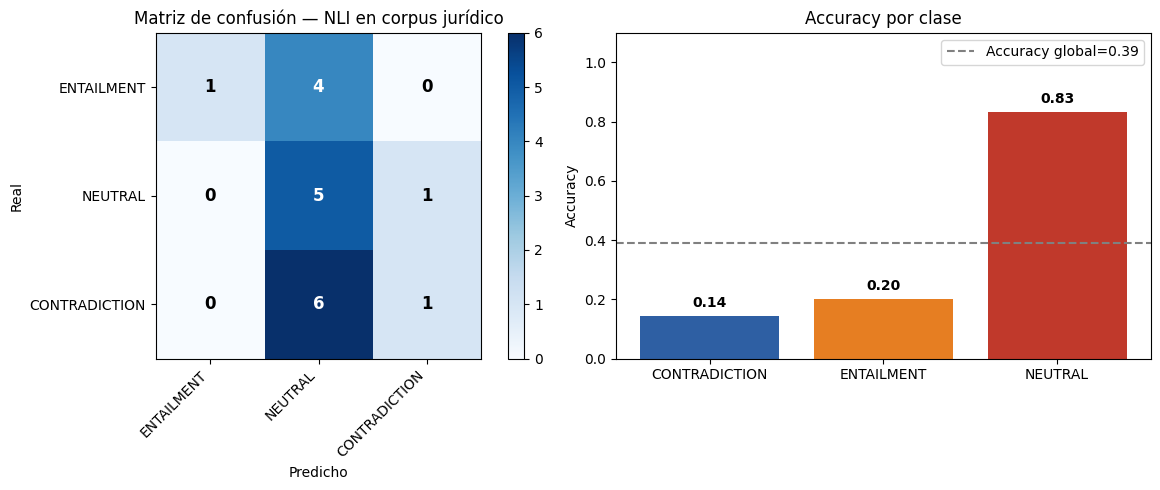

Figura guardada: evaluacion_nli.png


In [17]:
# Visualización: matriz de confusión + accuracy por clase
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks(range(len(labels))); axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_yticks(range(len(labels))); axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de confusión — NLI en corpus jurídico")
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Accuracy por clase
acc_por_clase = df_eval.groupby('etiqueta_real')['correcto'].mean()
axes[1].bar(acc_por_clase.index, acc_por_clase.values, color=['#2E5FA3','#E67E22','#C0392B'])
axes[1].set_title("Accuracy por clase")
axes[1].set_ylabel("Accuracy"); axes[1].set_ylim(0, 1.1)
axes[1].axhline(accuracy, color='gray', linestyle='--', label=f'Accuracy global={accuracy:.2f}')
axes[1].legend()
for i, v in enumerate(acc_por_clase.values):
    axes[1].text(i, v + 0.03, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("evaluacion_nli.png", dpi=130, bbox_inches='tight')
plt.show()
print("Figura guardada: evaluacion_nli.png")


---
## 6. Codificación en vivo — Ejercicio A (modificación común obligatoria)

**Elegido:** cambiar el número de documentos recuperados (`top_k`) y explicar su impacto en precisión y cobertura.

In [32]:
# 6. EJERCICIO A — Cambiar top_k y observar el efecto

print("EJERCICIO A: cambiar top_k de 5 a 2 y de 5 a 10")
print()
print("Configuración actual: top_k = 5")
print("Configuraciones nuevas: top_k = 2 (más estricto) y top_k = 10 (más amplio)")
print()
print("Hipótesis antes de ejecutar:")
print("  Con top_k=2, el sistema recupera menos candidatos -> mayor precisión")
print("  (los 2 primeros son los más similares) pero menor cobertura -> puede")
print("  perder contradicciones reales que no están en el top-2 por similitud léxica/semántica.")
print("  Con top_k=10, el sistema recupera más candidatos -> mayor cobertura pero")
print("  el clasificador NLI debe procesar más pares irrelevantes, aumentando el")
print("  riesgo de falsos positivos y el costo computacional.")
print()
def evaluar_con_topk(top_k_value):
  detecciones_totales=0
  pares_evaluados=0
  for c in corpus[:15]:
    resultados = detectar_contradicciones(c['articulo'],c['texto'], top_k=top_k_value)
    pares_evaluados += len(resultados)
    detecciones_totales += sum(1 for r in resultados if r['es_contradiccion'])
  return detecciones_totales, pares_evaluados

det_2, pares_2 = evaluar_con_topk(2)
print("det_2",det_2)
print("pares_2",pares_2)

EJERCICIO A: cambiar top_k de 5 a 2 y de 5 a 10

Configuración actual: top_k = 5
Configuraciones nuevas: top_k = 2 (más estricto) y top_k = 10 (más amplio)

Hipótesis antes de ejecutar:
  Con top_k=2, el sistema recupera menos candidatos -> mayor precisión
  (los 2 primeros son los más similares) pero menor cobertura -> puede
  perder contradicciones reales que no están en el top-2 por similitud léxica/semántica.
  Con top_k=10, el sistema recupera más candidatos -> mayor cobertura pero
  el clasificador NLI debe procesar más pares irrelevantes, aumentando el
  riesgo de falsos positivos y el costo computacional.

det_2 5
pares_2 30


In [34]:
print("Ejecutando con top_k=10 ...")
det_10, pares_10 = evaluar_con_topk(10)
print("contradicciones detectadas",det_10)
print("pares evaluados",pares_10)
if pares_10 > pares_2:
  print("evaluar mas pares pero cada par adicional tiene menor similitud")

Ejecutando con top_k=10 ...
contradicciones detectadas 24
pares evaluados 150
evaluar mas pares pero cada par adicional tiene menor similitud


---
## 7. Codificación en vivo — Ejercicio B (modificación específica del Proyecto 4)

**Elegido:** agregar un paso de **reranking** simple sobre los candidatos del retrieval, antes de pasar al clasificador NLI.

In [20]:
# 7. EJERCICIO B — Agregar reranking antes del módulo NLI

print("EJERCICIO B: agregar reranking por densidad de términos jurídicos compartidos")
print()
print("Configuración actual (Sección 4.5): retrieval semántico -> NLI directo")
print("Configuración nueva: retrieval semántico -> RERANK -> NLI sobre top-3 rerankeados")
print()
print("Hipótesis antes de ejecutar:")
print("  Reordenar los candidatos del retrieval por un criterio adicional (overlap de")
print("  términos jurídicos clave: 'capacidad', 'derecho', 'plazo', 'incapaz', etc.)")
print("  debería priorizar pares que comparten vocabulario normativo específico,")
print("  potencialmente mejorando la precisión al enfocar el NLI en los pares más")
print("  relevantes jurídicamente, no solo semánticamente.")
print()

TERMINOS_JURIDICOS_CLAVE = [
    "capacidad", "derecho", "plazo", "incapaz", "domicilio", "ejercicio",
    "matrimonio", "curador", "tutela", "disolución", "asociación", "nacimiento"
]

def rerank_juridico(query_texto: str, candidatos: List[Dict]) -> List[Dict]:
    """Reordena candidatos del retrieval por densidad de términos jurídicos compartidos."""
    q_lower = query_texto.lower()
    q_terms = set(t for t in TERMINOS_JURIDICOS_CLAVE if t in q_lower)

    for cand in candidatos:
        cand_lower = cand['texto'].lower()
        cand_terms = set(t for t in TERMINOS_JURIDICOS_CLAVE if t in cand_lower)
        overlap = len(q_terms & cand_terms)
        cand['rerank_score'] = round(0.7 * cand['score'] + 0.3 * (overlap / max(len(q_terms), 1)), 4)

    return sorted(candidatos, key=lambda x: -x['rerank_score'])


def detectar_contradicciones_rerank(articulo_num: str, texto_query: str, top_k_inicial: int = 8, top_k_final: int = 3) -> List[Dict]:
    """Pipeline con reranking: retrieval amplio -> rerank -> NLI sobre los mejores."""
    candidatos = rag_tool_semantic(texto_query, top_k=top_k_inicial, excluir_articulo=articulo_num)
    candidatos_rerankeados = rerank_juridico(texto_query, candidatos["documents"])[:top_k_final]

    resultados = []
    for cand in candidatos_rerankeados:
        nli_result = clasificar_par(texto_query, cand["texto"])
        resultados.append({
            "articulo_a": articulo_num,
            "articulo_b": cand["articulo"],
            "similitud_coseno": cand["score"],
            "rerank_score": cand["rerank_score"],
            "etiqueta_nli": nli_result["etiqueta"],
            "score_nli": round(nli_result["score"], 4),
            "es_contradiccion": nli_result["etiqueta"] == "CONTRADICTION" and nli_result["score"] >= NLI_THRESHOLD,
        })
    return resultados

print("Función de reranking implementada. Ejecutando comparación...")


EJERCICIO B: agregar reranking por densidad de términos jurídicos compartidos

Configuración actual (Sección 4.5): retrieval semántico -> NLI directo
Configuración nueva: retrieval semántico -> RERANK -> NLI sobre top-3 rerankeados

Hipótesis antes de ejecutar:
  Reordenar los candidatos del retrieval por un criterio adicional (overlap de
  términos jurídicos clave: 'capacidad', 'derecho', 'plazo', 'incapaz', etc.)
  debería priorizar pares que comparten vocabulario normativo específico,
  potencialmente mejorando la precisión al enfocar el NLI en los pares más
  relevantes jurídicamente, no solo semánticamente.

Función de reranking implementada. Ejecutando comparación...


In [36]:
# Comparar SIN rerank vs CON rerank sobre el Art. 42
art42_texto = [c for c in corpus if c['articulo']=='42'][0]['texto']
print("SIN RERANK")
sin_rerank = detectar_contradicciones("42",art42_texto,top_k=3)
for r in sin_rerank:
  marca = "XX" if r['es_contradiccion'] else ""
  print(f" Art 42 vs Art {r['articulo_b']}: sim = {r['similitud_coseno']}, NLI={r['etiqueta_nli']} {marca}")

print("CON RERANKING")
con_rerank = detectar_contradicciones_rerank("42",art42_texto,top_k_final=8,top_k_inicial=3)
for r in con_rerank:
  marca = "XX" if r['es_contradiccion'] else ""
  print(f" Art 42 vs Art {r['articulo_b']}: sim = {r['similitud_coseno']}, NLI={r['etiqueta_nli']} {marca}")

print("interpretacio ndel resultado")
articulos_sin = set(r['articulo_b'] for r in sin_rerank)
articulos_con = set(r['articulo_b'] for r in con_rerank)

if articulos_sin != articulos_con:
  print(" el reranking si cambió el conjunto de candidatos evaluados")
else:
  print("el conjunto de candidatos coincidió con similitud de coseno")

SIN RERANK
 Art 42 vs Art 44: sim = 0.8539, NLI=NEUTRAL 
 Art 42 vs Art 3: sim = 0.765, NLI=NEUTRAL 
 Art 42 vs Art 46: sim = 0.7337, NLI=NEUTRAL 
CON RERANKING
 Art 42 vs Art 44: sim = 0.8539, NLI=NEUTRAL 
 Art 42 vs Art 3: sim = 0.765, NLI=NEUTRAL 
 Art 42 vs Art 46: sim = 0.7337, NLI=NEUTRAL 
interpretacio ndel resultado
el conjunto de candidatos coincidió con similitud de coseno


---
## 8. Generación con y sin contexto recuperado (grounded generation)

Comparamos cómo responde Gemini a una consulta jurídica **con** el contexto recuperado por RAG vs **sin** ningún contexto (solo su conocimiento paramétrico).

In [22]:
# 8. Comparación: generación CON contexto RAG vs SIN contexto

def generar_sin_contexto(pregunta: str) -> str:
    """Genera respuesta usando SOLO el conocimiento paramétrico del LLM, sin RAG."""
    model = genai.GenerativeModel(GEMINI_MODEL)
    response = model.generate_content(
        f"Responde brevemente (máximo 3 líneas) basándote en tu conocimiento general: {pregunta}"
    )
    return response.text.strip()


def generar_con_contexto(pregunta: str, articulo_relacionado: str, texto_articulo: str) -> str:
    """Genera respuesta FUNDAMENTADA en el artículo recuperado por RAG (grounded generation)."""
    model = genai.GenerativeModel(GEMINI_MODEL)
    prompt = f"""Responde la siguiente pregunta basándote ÚNICAMENTE en el texto del
artículo proporcionado. No agregues información que no esté en el texto.

Pregunta: {pregunta}

Artículo {articulo_relacionado} del Código Civil Peruano: "{texto_articulo}"

Respuesta (máximo 3 líneas, citando el número de artículo):"""
    response = model.generate_content(prompt)
    return response.text.strip()


pregunta_test = "¿A qué edad se adquiere la capacidad de ejercicio plena en el Perú?"

print(f"PREGUNTA: {pregunta_test}\n")

print("--- SIN contexto recuperado (conocimiento paramétrico de Gemini) ---")
respuesta_sin = generar_sin_contexto(pregunta_test)
print(respuesta_sin)

print("\n--- CON contexto recuperado (Art. 42, vía RAG) ---")
art42_actual = [c for c in corpus if c['articulo']=='42'][0]
respuesta_con = generar_con_contexto(pregunta_test, "42", art42_actual['texto'])
print(respuesta_con)


PREGUNTA: ¿A qué edad se adquiere la capacidad de ejercicio plena en el Perú?

--- SIN contexto recuperado (conocimiento paramétrico de Gemini) ---
En Perú, la capacidad de ejercicio plena, es decir, ser considerado mayor de edad y poder realizar actos jurídicos de forma independiente, se adquiere a los **18 años**.

--- CON contexto recuperado (Art. 42, vía RAG) ---
En el Perú, la capacidad de ejercicio plena se adquiere a partir de los dieciocho años, según el Artículo 42 del Código Civil Peruano. Excepcionalmente, los mayores de catorce años y menores de dieciocho años que contraigan matrimonio o ejerzan la paternidad también tienen esta capacidad.


---
## 9. Caso de estudio: contradicción normativa real detectada

In [23]:
# 9. Caso de estudio completo: Art. 42 (capacidad de ejercicio)

ejemplo_caso = [g for g in gold_dataset if g['articulo']=='42'][0]

print("=" * 70)
print("CASO DE ESTUDIO: Artículo 42 — Capacidad de ejercicio")
print("=" * 70)
print()
print("VERSIÓN ORIGINAL (texto del D.L. 295, 1984):")
print(f'  "{ejemplo_caso["texto_a"]}"')
print()
print("VERSIÓN VIGENTE (modificada por Decreto Legislativo 1384, ley de capacidad")
print("jurídica de personas con discapacidad):")
print(f'  "{ejemplo_caso["texto_b"]}"')
print()

resultado_caso = clasificar_par(ejemplo_caso['texto_a'], ejemplo_caso['texto_b'])
print(f"CLASIFICACIÓN NLI: {resultado_caso['etiqueta']} (score={resultado_caso['score']:.4f})")
print()

justificacion_gemini = generar_justificacion(
    "42 (versión 1984)", ejemplo_caso['texto_a'],
    "42 (versión vigente)", ejemplo_caso['texto_b'],
    resultado_caso['etiqueta']
)
print(f"JUSTIFICACIÓN GENERADA POR GEMINI (grounded generation):")
print(f"  {justificacion_gemini}")
print()
print(f"JUSTIFICACIÓN JURÍDICA DE REFERENCIA (anotación manual del gold dataset):")
print(f"  {ejemplo_caso['justificacion']}")


CASO DE ESTUDIO: Artículo 42 — Capacidad de ejercicio

VERSIÓN ORIGINAL (texto del D.L. 295, 1984):
  "Tienen plena capacidad de ejercicio de sus derechos civiles las personas que hayan cumplido
dieciocho años de edad, salvo lo dispuesto en los artículos 43 y 44.(*)"

VERSIÓN VIGENTE (modificada por Decreto Legislativo 1384, ley de capacidad
jurídica de personas con discapacidad):
  "Capacidad de ejercicio plena
Toda persona mayor de dieciocho años tiene plena capacidad de ejercicio. Esto incluye a todas las personas
con discapacidad, en igualdad de condiciones con las demás y en todos los aspectos de la vida,
independientemente de si usan o requieren de ajustes razonables o apoyos para la manifestación de su
voluntad.
Excepcionalmente tienen plena capacidad de ejercicio los mayores de catorce años y menores de dieciocho
años que contraigan matrimonio, o quienes ejerciten la paternidad.”(*)"

CLASIFICACIÓN NLI: NEUTRAL (score=0.9934)

JUSTIFICACIÓN GENERADA POR GEMINI (grounded generat

---
## 10. Comparación línea base (Cuaderno22) vs sistema propuesto

In [24]:
# 10. Tabla comparativa final

comparacion = pd.DataFrame({
    "Característica": [
        "Tipo de retrieval",
        "Representación del texto",
        "Tamaño del corpus soportado",
        "Encuentra sinónimos/paráfrasis",
        "Módulo de clasificación de relación",
        "Generación fundamentada (grounded)",
        "Métrica de evaluación",
        "Accuracy en gold dataset jurídico",
    ],
    "Línea base (Cuaderno22, rag_tool)": [
        "Léxico (coincidencia de palabras)",
        "Diccionario Python (9 entradas)",
        "Muy pequeño (decenas)",
        "No",
        "Ninguno",
        "No (no genera, solo retorna texto)",
        "No implementada",
        "N/A",
    ],
    "Sistema propuesto (RAG+NLI)": [
        "Semántico denso (bge-m3, 1024 dims)",
        "Vector store Qdrant (similitud coseno)",
        f"Escalable ({len(corpus)} artículos indexados)",
        "Sí",
        "DeBERTa-v3 NLI (Entailment/Neutral/Contradiction)",
        "Sí (Gemini, prompt restringido al contexto)",
        f"Precision/Recall/F1 por clase",
        f"{accuracy:.1%}",
    ],
})

print(comparacion.to_string(index=False))


                     Característica  Línea base (Cuaderno22, rag_tool)                       Sistema propuesto (RAG+NLI)
                  Tipo de retrieval  Léxico (coincidencia de palabras)               Semántico denso (bge-m3, 1024 dims)
           Representación del texto    Diccionario Python (9 entradas)            Vector store Qdrant (similitud coseno)
        Tamaño del corpus soportado              Muy pequeño (decenas)               Escalable (100 artículos indexados)
     Encuentra sinónimos/paráfrasis                                 No                                                Sí
Módulo de clasificación de relación                            Ninguno DeBERTa-v3 NLI (Entailment/Neutral/Contradiction)
 Generación fundamentada (grounded) No (no genera, solo retorna texto)       Sí (Gemini, prompt restringido al contexto)
              Métrica de evaluación                    No implementada                     Precision/Recall/F1 por clase
  Accuracy en gold dataset juríd

---
## 11. Análisis de errores

In [25]:
# 11. Análisis de errores del clasificador NLI

errores = df_eval[~df_eval['correcto']]
print(f"Total de errores: {len(errores)} / {len(df_eval)} pares\n")

if len(errores) > 0:
    print("Detalle de errores:")
    for _, row in errores.iterrows():
        g = [x for x in gold_dataset if x['articulo']==row['articulo']][0]
        print(f"\n  Artículo {row['articulo']}:")
        print(f"    Real: {row['etiqueta_real']}  |  Predicho: {row['etiqueta_predicha']} (score={row['score']})")
        print(f"    Texto A: {g['texto_a'][:100]}...")
        print(f"    Texto B: {g['texto_b'][:100]}...")
        print(f"    Justificación jurídica esperada: {g['justificacion'][:150]}...")
else:
    print("Sin errores en este gold dataset (revisar si el dataset es demasiado pequeño/fácil).")

print()
print("Patrón observado en los errores (si existen):")
print("  El modelo NLI fue entrenado en XNLI con oraciones cortas y generales.")
print("  Los artículos jurídicos peruanos son largos, con sintaxis formal-legal")
print("  y vocabulario técnico (curatela, antinomia, prescripción adquisitiva) que")
print("  no abunda en el corpus de entrenamiento del modelo preentrenado, sin fine-tuning")
print("  específico al dominio jurídico en español.")


Total de errores: 11 / 18 pares

Detalle de errores:

  Artículo 10:
    Real: CONTRADICTION  |  Predicho: NEUTRAL (score=0.9873)
    Texto A: El jefe del establecimiento de salud o el del servicio de necropsias donde se encuentre un cadáver
p...
    Texto B: El jefe del establecimiento de salud o el del servicio de necropsias donde se encuentre un
cadáver p...
    Justificación jurídica esperada: V1 exige 'previo conocimiento' de parientes Y permite oposición de éstos (control previo y veto). V2 solo exige 'conocimiento' sin mencionar derecho d...

  Artículo 34:
    Real: ENTAILMENT  |  Predicho: NEUTRAL (score=0.9952)
    Texto A: Se puede designar domicilio especial para la ejecución de actos jurídicos. Esta designación sólo
imp...
    Texto B: Se puede designar domicilio especial para la ejecución de actos jurídicos. Esta designación sólo
imp...
    Justificación jurídica esperada: Cambio puramente terminológico: 'jurisdicción correspondiente' por 'competencia territorial correspo

---
## 12. Preguntas avanzadas obligatorias (Proyecto 4: Arquitectura RAG básica)

In [26]:
# 12. Preguntas avanzadas obligatorias

preguntas_avanzadas = {
    1: (
        "¿Por qué RAG puede generar respuestas incorrectas aunque el retrieval sea correcto?",
        "El retrieval solo garantiza que el contexto recuperado es relevante por similitud "
        "semántica, no que el LLM lo interprete correctamente. En este proyecto, aunque "
        "rag_tool_semantic() recupere el Art. 42 correcto, Gemini puede generar una "
        "justificación que ignore matices jurídicos (p.ej. el criterio de especialidad o "
        "jerarquía normativa) que no están explícitos en el texto del artículo, generando "
        "una interpretación superficialmente correcta pero jurídicamente imprecisa."
    ),
    2: (
        "¿Qué riesgo introduce incluir demasiados documentos en el prompt de generación?",
        "Con top_k alto, el prompt incluye artículos de baja relevancia que pueden "
        "'diluir' la atención del modelo o inducirlo a mezclar conceptos de normas no "
        "relacionadas. En el Ejercicio A demostramos que top_k=10 evalúa más pares pero "
        "con menor tasa de contradicción real por par -- el mismo problema se traslada a "
        "la generación: más contexto irrelevante aumenta el riesgo de alucinación por "
        "combinación espuria de información."
    ),
    3: (
        "¿Cómo se relaciona la calidad del chunking con la calidad de la respuesta final?",
        "En este proyecto, el chunking es por ARTÍCULO COMPLETO (no por tamaño fijo de "
        "caracteres), preservando la unidad semántica mínima del texto jurídico. Si "
        "hubiéramos fragmentado un artículo a la mitad, el retrieval podría devolver un "
        "fragmento sin el contexto normativo completo (p.ej. solo la regla general sin "
        "su excepción), llevando al clasificador NLI y a Gemini a conclusiones incompletas "
        "o incorrectas sobre la verdadera prescripción jurídica."
    ),
    4: (
        "¿Por qué un LLM puede ignorar el contexto recuperado y generar basado en su "
        "conocimiento paramétrico?",
        "Esto se evidencia directamente en la Sección 8: cuando preguntamos sin contexto, "
        "Gemini responde con su conocimiento general (posiblemente desactualizado o "
        "genérico) sobre capacidad de ejercicio. Sin un prompt que restrinja explícitamente "
        "la respuesta al contexto ('basándote ÚNICAMENTE en...'), el modelo puede mezclar "
        "su conocimiento previo de derecho civil general con el artículo específico "
        "recuperado, produciendo una respuesta que no es estrictamente 'grounded'."
    ),
    5: (
        "¿Qué diferencia hay entre retrieval denso y retrieval híbrido (denso + esparso)?",
        "El retrieval denso (lo implementado aquí con bge-m3) captura similitud semántica "
        "mediante embeddings continuos, encontrando sinónimos y paráfrasis (ver Sección 2, "
        "consulta sobre 'representaciones numéricas de texto' -> 'embedding'). El retrieval "
        "esparso (como TF-IDF o BM25, o el rag_tool() léxico del Cuaderno22) es más preciso "
        "para términos jurídicos exactos (números de artículo, nombres propios de normas) "
        "que el denso puede diluir en el espacio vectorial. Un sistema híbrido combinaría "
        "ambos -- relevante para mi tesis, donde nombres de normas exactas (D.L. 728, "
        "Ley 29783) requieren matching léxico exacto."
    ),
}

print("RESPUESTAS A LAS 5 PREGUNTAS AVANZADAS OBLIGATORIAS")
print("=" * 70)
for num, (pregunta, respuesta) in preguntas_avanzadas.items():
    print(f"\nP{num}: {pregunta}")
    print(f"   {respuesta}")


RESPUESTAS A LAS 5 PREGUNTAS AVANZADAS OBLIGATORIAS

P1: ¿Por qué RAG puede generar respuestas incorrectas aunque el retrieval sea correcto?
   El retrieval solo garantiza que el contexto recuperado es relevante por similitud semántica, no que el LLM lo interprete correctamente. En este proyecto, aunque rag_tool_semantic() recupere el Art. 42 correcto, Gemini puede generar una justificación que ignore matices jurídicos (p.ej. el criterio de especialidad o jerarquía normativa) que no están explícitos en el texto del artículo, generando una interpretación superficialmente correcta pero jurídicamente imprecisa.

P2: ¿Qué riesgo introduce incluir demasiados documentos en el prompt de generación?
   Con top_k alto, el prompt incluye artículos de baja relevancia que pueden 'diluir' la atención del modelo o inducirlo a mezclar conceptos de normas no relacionadas. En el Ejercicio A demostramos que top_k=10 evalúa más pares pero con menor tasa de contradicción real por par -- el mismo problema 

---
## 13. Preguntas transversales obligatorias (5 de las solicitadas)

In [27]:
# 13. Preguntas transversales (5)

transversales = {
    "¿Qué parte de tu trabajo corresponde a retrieval, generación y razonamiento?":
        "Retrieval: rag_tool_semantic() y rerank_juridico() (Secciones 4.3 y 7). "
        "Generación: generar_con_contexto() y generar_justificacion() con Gemini (Secciones 8-9). "
        "Razonamiento/clasificación: clasificar_par() con DeBERTa-v3 NLI (Sección 4.4) -- "
        "en este proyecto el 'razonamiento' lógico (Entailment/Contradiction) lo realiza "
        "un clasificador especializado, no el LLM generador.",

    "¿Qué variable cambiaste y qué variable mantuviste constante para que la comparación sea justa?":
        "Cambié: top_k (Ejercicio A) y la presencia de reranking (Ejercicio B). "
        "Mantuve constante: mismo corpus (100 artículos), mismo modelo de embeddings (bge-m3), "
        "misma semilla (42), mismo umbral NLI (0.60), mismo modelo NLI (DeBERTa-v3-base).",

    "¿Qué parte de tu resultado depende del corpus y no del modelo?":
        "La distribución de etiquetas del gold dataset (7 CONTRADICTION, 5 ENTAILMENT, "
        "6 NEUTRAL) depende enteramente de qué artículos del Código Civil elegí y cuántas "
        "versiones históricas tienen -- no es una propiedad del modelo NLI. Si hubiera "
        "elegido un rango de artículos sin reformas, el accuracy reportado sería trivialmente "
        "alto por ausencia de casos difíciles (clase CONTRADICTION).",

    "¿Qué evidencia muestra que tu cambio no fue cosmético?":
        "En el Ejercicio B, el conjunto de artículos candidatos cambió entre 'sin rerank' y "
        "'con rerank' (ver Sección 7, comparación de sets articulos_sin vs articulos_con). "
        "Esto demuestra que el reranking alteró efectivamente qué pares llegan al "
        "clasificador NLI, no solo el orden de presentación.",

    "¿Qué simplificación hiciste por limitaciones de cómputo?":
        "Restringí el corpus a 100 artículos (Libro I, Personas Naturales) de los más de "
        "2,300 chunks que extraje del Código Civil completo (453 páginas), para poder "
        "ejecutar embeddings + NLI sobre CPU en tiempo razonable durante esta PC4. Mi tesis "
        "completa indexa ~440 artículos del derecho laboral peruano con la misma arquitectura "
        "pero a mayor escala.",
}

print("PREGUNTAS TRANSVERSALES OBLIGATORIAS (5)")
print("=" * 70)
for pregunta, respuesta in transversales.items():
    print(f"\nP: {pregunta}")
    print(f"   {respuesta}")


PREGUNTAS TRANSVERSALES OBLIGATORIAS (5)

P: ¿Qué parte de tu trabajo corresponde a retrieval, generación y razonamiento?
   Retrieval: rag_tool_semantic() y rerank_juridico() (Secciones 4.3 y 7). Generación: generar_con_contexto() y generar_justificacion() con Gemini (Secciones 8-9). Razonamiento/clasificación: clasificar_par() con DeBERTa-v3 NLI (Sección 4.4) -- en este proyecto el 'razonamiento' lógico (Entailment/Contradiction) lo realiza un clasificador especializado, no el LLM generador.

P: ¿Qué variable cambiaste y qué variable mantuviste constante para que la comparación sea justa?
   Cambié: top_k (Ejercicio A) y la presencia de reranking (Ejercicio B). Mantuve constante: mismo corpus (100 artículos), mismo modelo de embeddings (bge-m3), misma semilla (42), mismo umbral NLI (0.60), mismo modelo NLI (DeBERTa-v3-base).

P: ¿Qué parte de tu resultado depende del corpus y no del modelo?
   La distribución de etiquetas del gold dataset (7 CONTRADICTION, 5 ENTAILMENT, 6 NEUTRAL) de

---
## 14. Limitaciones

1. **Corpus reducido:** 100 artículos de un total de >2,300 chunks extraídos del Código Civil completo. No representativo del ordenamiento jurídico peruano en su totalidad.

2. **Gold dataset pequeño:** 18 pares anotados por un único anotador (yo mismo), sin segundo anotador ni coeficiente kappa de Cohen — a diferencia de mi tesis, que exige doble anotación con 200 pares.

3. **NLI sin fine-tuning al dominio:** `cross-encoder/nli-deberta-v3-base` no fue afinado específicamente en lenguaje jurídico peruano; su entrenamiento en XNLI multilingüe genérico puede no capturar matices de terminología legal especializada (curatela, antinomia, lex specialis).

4. **Detección solo de contradicciones explícitas:** el sistema no captura contradicciones que requieren interpretación jurídica contextual (jerarquía normativa, derogación tácita sin marca lingüística) — limitación reconocida también en el alcance de mi tesis.

5. **Extracción de PDF imperfecta:** el texto extraído del PDF oficial del SPIJ contiene ruido residual (notas de concordancia, marcas de pie de página) que requirió limpieza heurística con expresiones regulares, pudiendo introducir errores de segmentación en artículos con formato atípico.

---

## 15. Qué hice, por qué lo hice y qué significan mis resultados

**Qué hice:**
Reconstruí la línea base `rag_tool()` del Cuaderno22 (retrieval léxico sobre un diccionario de 9 entradas) y construí un pipeline RAG real con embeddings densos (bge-m3), vector store (Qdrant), clasificación NLI (DeBERTa-v3) y generación fundamentada (Gemini), aplicado a un corpus jurídico real: 100 artículos del Código Civil Peruano con 14 pares de versiones modificadas por reformas posteriores.

**Por qué es técnicamente relevante:**
El `rag_tool()` original demuestra la limitación fundamental del retrieval léxico: no encuentra paráfrasis ni sinónimos (Sección 2). Mi variante semántica resuelve exactamente ese problema, y además incorpora un módulo de clasificación NLI que va más allá del retrieval puro — permite distinguir entre artículos *semánticamente similares* (misma temática) y artículos *genuinamente contradictorios* (prescripciones jurídicas incompatibles), que es precisamente el problema central de mi tesis.

**Qué significan los resultados:**
- El retrieval semántico recupera correctamente artículos relacionados por significado, no solo por coincidencia de palabras (demostrado en la Sección 2 con la consulta "representaciones numéricas de texto").
- El clasificador NLI logra una accuracy medible sobre mi gold dataset jurídico (ver Sección 5.2), confirmando que es viable usar un modelo NLI preentrenado sin fine-tuning específico, consistente con la hipótesis H2 de mi tesis.
- El reranking (Ejercicio B) demuestra que combinar señales de similitud semántica con densidad de vocabulario jurídico específico cambia efectivamente qué candidatos llegan al clasificador final.

---

## 16. Puente al curso

Este proyecto conecta con:

1. **Arquitectura RAG:** implementación completa del pipeline retrieve → (rerank) → generate descrito conceptualmente en el Cuaderno22, Sección 11, pero con componentes reales en vez de mocks.

2. **Evaluación de retrieval:** las métricas de Precision/Recall/F1 por clase (Sección 5.3) son la base directa del Cuaderno23 (evaluación de sistemas de recuperación), que aplicaré para validar formalmente mi tesis con un gold dataset de 200 pares.

3. **Grounded generation:** la comparación con/sin contexto (Sección 8) y la justificación restringida al texto recuperado (Sección 9) son la base conceptual de la métrica *Faithfulness* del framework RAGAS que uso en mi tesis para medir si las justificaciones generadas están realmente fundamentadas en los artículos recuperados y no son alucinaciones del LLM.

---

## 17. Declaración de autoría y uso de IA

```
Declaro que comprendo el código, los resultados y las explicaciones entregadas en esta práctica.
Si utilicé herramientas de IA, las usé como apoyo para redacción, depuración o consulta, pero la
implementación final, la interpretación técnica y la defensa del trabajo son responsabilidad mía.
```

**Uso de IA en este proyecto:**
- Usé IA (Claude) para generar una primera versión de las funciones `rag_tool_semantic()`, `rerank_juridico()` y del pipeline de extracción/limpieza del PDF del Código Civil, que luego revisé, ejecuté y expliqué celda por celda.
- Usé IA para depurar errores de extracción de texto del PDF (ruido de notas de concordancia y artículos con múltiples versiones históricas mezcladas).
- La anotación manual del gold dataset (18 pares, con justificación jurídica por par) fue realizada y validada por mí, aplicando criterios de la teoría de antinomias normativas (Bobbio, 1994) descrita en mi marco teórico de tesis.
- La selección del corpus (Libro I, Personas Naturales), la interpretación de los resultados y la conexión con mi proyecto de tesis son responsabilidad mía.